# ANN: Predicting frustration from heart rate (HR)

This notebook builds an artificial neural network (an `MLPClassifier`, single hidden layer) that
predicts whether someone is frustrated or not, based on the heart-rate features in `HR_data.csv`.

We follow the same approach as `logistic_regression_training.ipynb`, so the two models are
comparable: per-individual normalization of the HR features, then nested Leave-One-Subject-Out
(LOSO) cross-validation. The outer loop (`LeaveOneGroupOut`) holds out one individual at a time
across 14 folds; an inner `StratifiedGroupKFold` loop on the remaining 13 individuals, together
with `RandomizedSearchCV`, picks the network's hyperparameters (hidden layer size, regularization,
activation, learning rate, batch size, number of epochs) and the decision threshold that
maximizes balanced accuracy,
without ever touching the held-out individual. All preprocessing sits inside a `Pipeline`, so it's
refit per fold and doesn't leak. After the LOSO loop, we fit one more model on all 14 individuals,
purely to look at permutation importance, the decision boundary, and the training loss curve.

Feature set: as in the logistic regression notebook, we use 5 (per-individual normalized) HR
features (`HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`, `HR_AUC`), dropping `HR_Min`, plus one-hot
encoded `Phase` and `Round`. No automatic feature selection is applied.

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    LeaveOneGroupOut,
    StratifiedGroupKFold,
    RandomizedSearchCV,
    cross_val_predict,
)
from scipy.stats import loguniform
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)

## 1. Load data

In [2]:
df = pd.read_csv("HR_data.csv", index_col=0)
df.head()

,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HR_Mean     168 non-null    float64
 1   HR_Median   168 non-null    float64
 2   HR_std      168 non-null    float64
 3   HR_Min      168 non-null    float64
 4   HR_Max      168 non-null    float64
 5   HR_AUC      168 non-null    float64
 6   Round       168 non-null    str    
 7   Phase       168 non-null    str    
 8   Individual  168 non-null    int64  
 9   Puzzler     168 non-null    int64  
 10  Frustrated  168 non-null    int64  
 11  Cohort      168 non-null    str    
dtypes: float64(6), int64(3), str(3)
memory usage: 15.9 KB


,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Individual,Puzzler,Frustrated
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.00000,168.000000,168.000000
mean,76.009226,74.821458,6.041234,67.422679,89.062024,23398.551815,7.50000,0.500000,2.291667
std,7.501301,8.101459,4.267282,7.042010,12.764559,3589.600223,4.04318,0.501495,1.924796
min,57.341463,54.130000,0.844255,52.180000,70.150000,15975.450000,1.00000,0.000000,0.000000
25%,70.952240,70.175000,3.092851,62.645000,79.752500,20805.553750,4.00000,0.000000,1.000000
50%,75.618503,74.625000,4.678773,67.540000,87.355000,22493.687500,7.50000,0.500000,2.000000
75%,80.308459,79.010000,7.281001,71.922500,94.682500,25645.200000,11.00000,1.000000,4.000000
max,96.159341,94.880000,21.880307,82.680000,137.670000,35299.460000,14.00000,1.000000,8.000000


## 2. Convert frustration into a binary variable

`Frustrated` ranges from 0 to 8 in the dataset. We choose a threshold (`threshold`), so that all values >= threshold become class 1 ("frustrated"), and all values below become class 0 ("not frustrated").

You can change `threshold` to see how the class balance and the model's performance change.


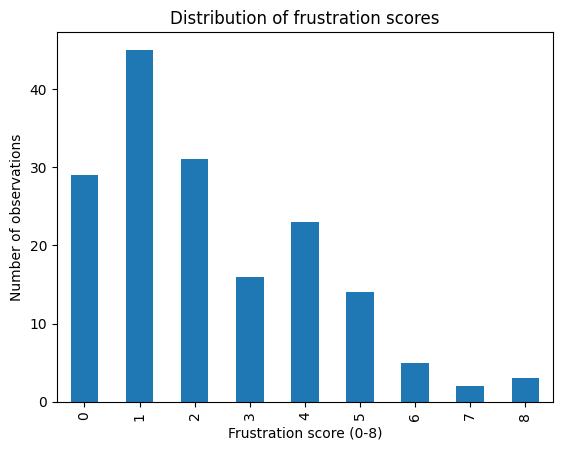

In [4]:
# Distribution of the raw frustration scores
df["Frustrated"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Frustration score (0-8)")
plt.ylabel("Number of observations")
plt.title("Distribution of frustration scores")
plt.show()


In [5]:
threshold = 3  # adjust as needed (>= threshold => frustrated = 1)

df["Frustrated_binary"] = (df["Frustrated"] >= threshold).astype(int)

print(df["Frustrated_binary"].value_counts())
print(f"\nProportion frustrated (class 1): {df['Frustrated_binary'].mean():.2%}")


Frustrated_binary
0    105
1     63
Name: count, dtype: int64

Proportion frustrated (class 1): 37.50%


## 3. Per-individual normalization of HR features

Resting heart rate and heart-rate variability differ a lot from person to person (fitness level,
age, caffeine, etc.), and that between-person variation can drown out the within-person variation
that actually relates to frustration - i.e. whether someone's heart rate is higher or lower than
*their own* normal level.

So for each HR feature we z-score it per individual: subtract that person's own mean and divide by
their own standard deviation (computed across their 12 measurements). What's left is how many
standard deviations a given measurement is from that person's normal level.

This assumes a new individual would also have a short calibration/baseline period to compute their
own mean and std from, which fits the experiment's design (each round starts with a rest phase), so
it still makes sense for predicting on people the model hasn't seen before.

In [6]:
raw_feature_cols = ["HR_Mean", "HR_Median", "HR_std", "HR_Max", "HR_AUC"]

df_norm = df.copy()
for col in raw_feature_cols:
    df_norm[col] = df.groupby("Individual")[col].transform(lambda s: (s - s.mean()) / s.std())

df_norm[raw_feature_cols].describe()

,HR_Mean,HR_Median,HR_std,HR_Max,HR_AUC
count,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02
mean,6.079793e-17,-1.059999e-15,-3.700743e-17,-5.709718e-16,-6.079793e-17
std,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01
min,-2.090416e+00,-2.320427e+00,-1.561129e+00,-1.751144e+00,-1.571144e+00
25%,-7.280204e-01,-7.704507e-01,-6.933782e-01,-7.559462e-01,-6.944055e-01
50%,-2.775503e-02,-8.617163e-02,-3.165731e-01,-2.086793e-01,-2.577854e-01
75%,6.248084e-01,6.679727e-01,5.324870e-01,5.103417e-01,5.597943e-01
max,2.091565e+00,2.416027e+00,2.897812e+00,2.546851e+00,2.937623e+00


## 4. Choose features, target and groups

As explained in the intro, we use the same 5 (per-individual normalized) HR features as the
logistic regression notebook. `Phase` and `Round` are excluded -- see `robustness_checks.ipynb`
Section 1 for why. No automatic feature selection is applied here either.

X is these 5 HR features, y is the binary frustration label, and `groups` is `Individual`, used
only to make sure a person's rows never end up split across the training and test sets.


In [7]:
feature_cols = raw_feature_cols  # Phase/Round excluded: see justification in the report

X = df_norm[feature_cols]
y = df_norm["Frustrated_binary"]
groups = df_norm["Individual"]

X.head()

,HR_Mean,HR_Median,HR_std,HR_Max,HR_AUC
0,1.097189,1.223550,-0.030634,0.495003,-0.255968
1,-1.593119,-1.723680,-0.714876,-0.999437,-0.547102
2,-0.672146,-0.616981,-0.101523,-0.419072,-0.630037
3,1.463764,1.175950,0.555938,0.944786,0.427252
4,0.849517,-0.144948,2.204090,2.462439,0.026698


### Features used in this model

This ANN is trained on the 5 preprocessed columns derived from `X` above - every fold's network
uses all of them, no feature selection happens anywhere:

- `HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`, `HR_AUC`, each z-scored per individual (Section 3)
  and then standardized again inside the pipeline's `ColumnTransformer`.

`HR_Min`, `Phase`, and `Round` aren't used as predictors (see Section 4), and neither is
`Individual` - that column only defines the LOSO splits so no individual's rows end up in both the
training and test set of a fold.


## 5. Nested Leave-One-Subject-Out (LOSO) cross-validation

Same idea as the logistic regression notebook: the outer loop (`LeaveOneGroupOut`) holds out one
individual at a time across 14 folds, and an inner `StratifiedGroupKFold` loop (3 folds this time)
on the remaining 13 individuals, together with `RandomizedSearchCV`, picks the ANN's
hyperparameters and the decision threshold that maximizes balanced accuracy, all within the outer training set. The
tuned pipeline is then refit on the 13 training individuals and evaluated once on the held-out one.

Since this random search now runs 14 times instead of once (14 outer folds x 20 configs x 3 inner
folds ~ 840 fits), we kept `n_iter` and the hyperparameter ranges smaller than we would for a
single train/test split, just to keep the runtime reasonable. The search covers:

- `hidden_layer_sizes`: number and size of hidden layers.
- `alpha`: L2 regularization strength (log-uniform).
- `activation`: `relu` or `tanh`.
- `learning_rate_init`: learning rate for the `adam` optimizer (log-uniform).
- `batch_size`: mini-batch size.
- `max_iter`: maximum number of epochs.

We scored on balanced accuracy rather than plain accuracy, so the search doesn't just settle for a
model that predicts the majority class every time.

In [8]:
preprocessor = ColumnTransformer([
    ("hr", StandardScaler(), raw_feature_cols),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", MLPClassifier(solver="adam", random_state=42)),
])

param_distributions = {
    "clf__hidden_layer_sizes": [
        (4,), (8,), (16,), (32,),
        (8, 8), (16, 8), (16, 16), (32, 16),
    ],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": loguniform(1e-4, 1e2),
    "clf__learning_rate_init": loguniform(1e-4, 1e-1),
    "clf__batch_size": [8, 16, 32, "auto"],
    "clf__max_iter": [200, 500, 1000],
}

n_iter_search = 20
outer_cv = LeaveOneGroupOut()

oof_true = np.zeros(len(y), dtype=int)
oof_pred = np.zeros(len(y), dtype=int)
oof_proba = np.zeros(len(y), dtype=float)
fold_records = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    groups_tr = groups.iloc[train_idx]
    test_individual = groups.iloc[test_idx].iloc[0]

    # Inner CV (13 training individuals): hyperparameter tuning
    inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
    random_search = RandomizedSearchCV(
        pipeline, param_distributions, n_iter=n_iter_search, cv=inner_cv,
        scoring="balanced_accuracy", n_jobs=-1, random_state=42,
    )
    random_search.fit(X_tr, y_tr, groups=groups_tr)
    best_model = random_search.best_estimator_

    # Inner CV out-of-fold probabilities: threshold selection (maximize balanced accuracy)
    inner_oof_proba = cross_val_predict(
        best_model, X_tr, y_tr, groups=groups_tr, cv=inner_cv, method="predict_proba"
    )[:, 1]
    fpr_in, tpr_in, thr_in = roc_curve(y_tr, inner_oof_proba)
    threshold = thr_in[np.argmax(tpr_in - fpr_in)]

    # Evaluate once on the held-out individual
    proba_te = best_model.predict_proba(X_te)[:, 1]
    pred_te = (proba_te >= threshold).astype(int)

    oof_true[test_idx] = y_te.values
    oof_proba[test_idx] = proba_te
    oof_pred[test_idx] = pred_te

    fold_records.append({
        "Individual": int(test_individual),
        "best_params": random_search.best_params_,
        "threshold": threshold,
        "accuracy": accuracy_score(y_te, pred_te),
        "balanced_accuracy": balanced_accuracy_score(y_te, pred_te),
    })

    print(f"Fold {fold_i + 1:2d}/14 (Individual {int(test_individual):2d}): "
          f"threshold={threshold:.3f}, accuracy={accuracy_score(y_te, pred_te):.3f}")

fold_df = pd.DataFrame(fold_records)
fold_df.drop(columns="best_params")

Fold  1/14 (Individual  1): threshold=0.346, accuracy=0.500


Fold  2/14 (Individual  2): threshold=0.585, accuracy=0.667


Fold  3/14 (Individual  3): threshold=0.464, accuracy=0.500


Fold  4/14 (Individual  4): threshold=0.047, accuracy=0.417


Fold  5/14 (Individual  5): threshold=0.193, accuracy=0.500


...

Fold 11/14 (Individual 11): threshold=0.017, accuracy=0.417


Fold 12/14 (Individual 12): threshold=0.312, accuracy=0.500


Fold 13/14 (Individual 13): threshold=0.503, accuracy=0.583


Fold 14/14 (Individual 14): threshold=0.353, accuracy=0.833


,Individual,threshold,accuracy,balanced_accuracy
0,1,0.346473,0.500000,0.555556
1,2,0.584558,0.666667,0.562500
2,3,0.463858,0.500000,0.625000
3,4,0.046704,0.416667,0.442857
4,5,0.193191,0.500000,0.514286
5,6,0.304531,0.416667,0.416667
6,7,0.400165,0.416667,0.500000
7,8,0.187101,0.500000,0.625000
8,9,0.506293,0.500000,0.437500
9,10,0.391126,0.333333,0.181818


## 6. Aggregated nested-LOSO performance

Each of the 168 rows now has exactly one out-of-fold prediction, from a model that never saw that
individual during training or tuning. Pooling all 168 together gives the headline numbers for this
notebook.

Nested LOSO accuracy:          0.506
Nested LOSO balanced accuracy: 0.506
Nested LOSO ROC-AUC:           0.448

Classification report (all 168 out-of-fold predictions):
                precision    recall  f1-score   support

Not frustrated       0.63      0.50      0.56       105
    Frustrated       0.38      0.51      0.44        63

      accuracy                           0.51       168
     macro avg       0.51      0.51      0.50       168
  weighted avg       0.54      0.51      0.51       168



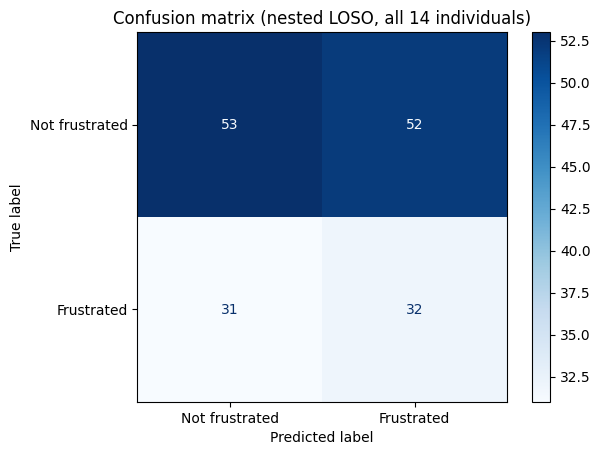

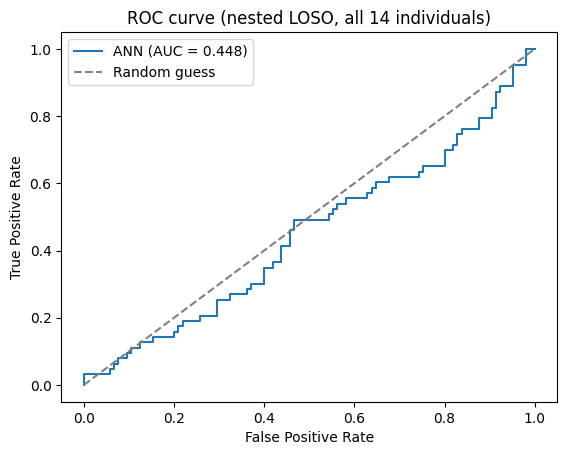

In [9]:
overall_accuracy = accuracy_score(oof_true, oof_pred)
overall_balanced_accuracy = balanced_accuracy_score(oof_true, oof_pred)
overall_auc = roc_auc_score(oof_true, oof_proba)

print(f"Nested LOSO accuracy:          {overall_accuracy:.3f}")
print(f"Nested LOSO balanced accuracy: {overall_balanced_accuracy:.3f}")
print(f"Nested LOSO ROC-AUC:           {overall_auc:.3f}\n")
print("Classification report (all 168 out-of-fold predictions):")
print(classification_report(oof_true, oof_pred, target_names=["Not frustrated", "Frustrated"], zero_division=0))

cm = confusion_matrix(oof_true, oof_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not frustrated", "Frustrated"])
disp.plot(cmap="Blues")
plt.title("Confusion matrix (nested LOSO, all 14 individuals)")
plt.show()

fpr, tpr, _ = roc_curve(oof_true, oof_proba)
plt.plot(fpr, tpr, label=f"ANN (AUC = {overall_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (nested LOSO, all 14 individuals)")
plt.legend()
plt.show()

## 7. Per-individual performance

Since each outer fold corresponds to one individual, we also get 14 separate
accuracy/balanced-accuracy scores. This is useful for checking whether performance is fairly
consistent across people, or mostly driven by a couple of easy or hard individuals.

 Individual  threshold  accuracy  balanced_accuracy
         10   0.391126  0.333333           0.181818
         13   0.503017  0.583333           0.318182
         11   0.016754  0.416667           0.388889
          6   0.304531  0.416667           0.416667
          9   0.506293  0.500000           0.437500
          4   0.046704  0.416667           0.442857
          7   0.400165  0.416667           0.500000
          5   0.193191  0.500000           0.514286
          1   0.346473  0.500000           0.555556
          2   0.584558  0.666667           0.562500
          3   0.463858  0.500000           0.625000
          8   0.187101  0.500000           0.625000
         12   0.311998  0.500000           0.666667
         14   0.353169  0.833333           0.857143

Mean per-individual accuracy:          0.506 ± 0.124
Mean per-individual balanced accuracy: 0.507 ± 0.165


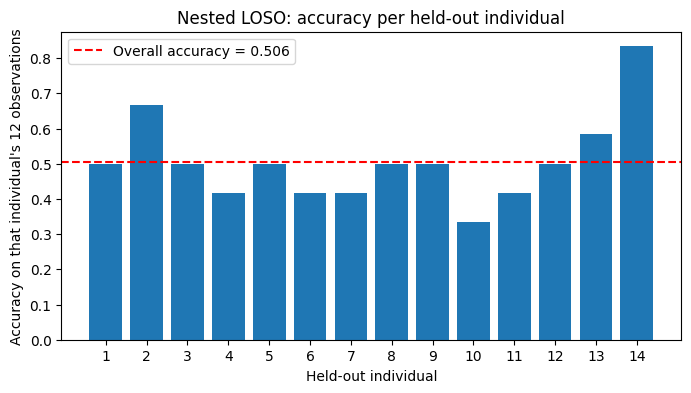

In [10]:
print(fold_df[["Individual", "threshold", "accuracy", "balanced_accuracy"]]
      .sort_values("balanced_accuracy").to_string(index=False))

print(f"\nMean per-individual accuracy:          {fold_df['accuracy'].mean():.3f} ± {fold_df['accuracy'].std():.3f}")
print(f"Mean per-individual balanced accuracy: {fold_df['balanced_accuracy'].mean():.3f} ± {fold_df['balanced_accuracy'].std():.3f}")

plt.figure(figsize=(8, 4))
plt.bar(fold_df["Individual"].astype(str), fold_df["accuracy"])
plt.axhline(overall_accuracy, color="red", linestyle="--", label=f"Overall accuracy = {overall_accuracy:.3f}")
plt.xlabel("Held-out individual")
plt.ylabel("Accuracy on that individual's 12 observations")
plt.title("Nested LOSO: accuracy per held-out individual")
plt.legend()
plt.show()

## 8. Final model (fit on all individuals) for interpretation

The LOSO loop above gives us 14 slightly different networks, one per fold, which is fine for
honest performance numbers but awkward for interpretation. So here we fit one more model, on all
14 individuals, using the exact same procedure, purely to look at permutation importance, the
decision boundary, and the training curve. It isn't used for any of the performance numbers, those
came from Section 6.

In [11]:
final_inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

final_search = RandomizedSearchCV(
    pipeline, param_distributions, n_iter=n_iter_search, cv=final_inner_cv,
    scoring="balanced_accuracy", n_jobs=-1, random_state=42,
)
final_search.fit(X, y, groups=groups)
final_model = final_search.best_estimator_

final_oof_proba = cross_val_predict(
    final_model, X, y, groups=groups, cv=final_inner_cv, method="predict_proba"
)[:, 1]
fpr_f, tpr_f, thr_f = roc_curve(y, final_oof_proba)
final_threshold = thr_f[np.argmax(tpr_f - fpr_f)]

print(f"Final model hyperparameters: {final_search.best_params_}")
print(f"Final model threshold (max balanced accuracy, full-data CV): {final_threshold:.3f}")

Final model hyperparameters: {'clf__activation': 'relu', 'clf__alpha': np.float64(0.047314746448150063), 'clf__batch_size': 32, 'clf__hidden_layer_sizes': (16,), 'clf__learning_rate_init': np.float64(0.002386418878005608), 'clf__max_iter': 200}
Final model threshold (max balanced accuracy, full-data CV): 0.450


## 9. Visualize the decision boundary (PCA)

The final model uses 5 standardized HR features, so its decision boundary can't be drawn directly
in 2D. Instead, we reduce the 5 preprocessed columns to 2 components with PCA (for visualization
only), build a fine grid in that space, project each grid point back to the 5-dimensional space
(`pca.inverse_transform`), and ask the final model for P(frustrated) at each point.

The color scale below is the predicted probability, and the black contour marks the final model's
decision threshold.


Explained variance: PC1 = 65.8%, PC2 = 21.4%, total = 87.2%


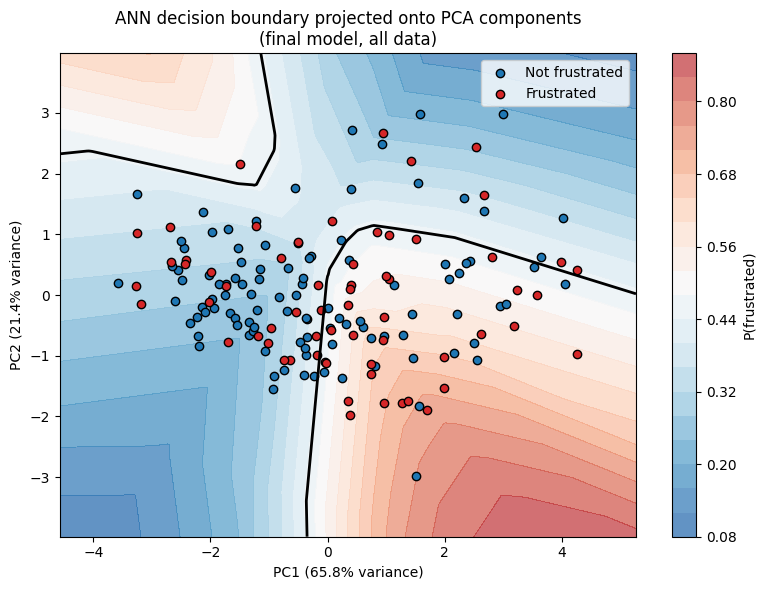

In [12]:
preprocessor_fitted = final_model.named_steps["preprocessor"]
clf = final_model.named_steps["clf"]

X_selected = preprocessor_fitted.transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_selected)

print(f"Explained variance: PC1 = {pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.1%}, "
      f"total = {pca.explained_variance_ratio_.sum():.1%}")

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Project the grid back to the preprocessed feature space and use the final model
grid_selected = pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
grid_proba = clf.predict_proba(grid_selected)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx, yy, grid_proba, levels=20, cmap="RdBu_r", alpha=0.7, vmin=0, vmax=1)
ax.contour(xx, yy, grid_proba, levels=[final_threshold], colors="black", linewidths=2)

ax.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], c="tab:blue", edgecolor="k", label="Not frustrated")
ax.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], c="tab:red", edgecolor="k", label="Frustrated")

fig.colorbar(contour, ax=ax, label="P(frustrated)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("ANN decision boundary projected onto PCA components\n(final model, all data)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Feature importance (permutation importance)

A neural network doesn't have simple coefficients like logistic regression, so instead we use
permutation importance on the final model: for each feature, we shuffle its values across the
whole dataset and see how much the model's balanced accuracy drops. A bigger drop means the model
relies more on that feature; a drop near 0 means it barely matters.

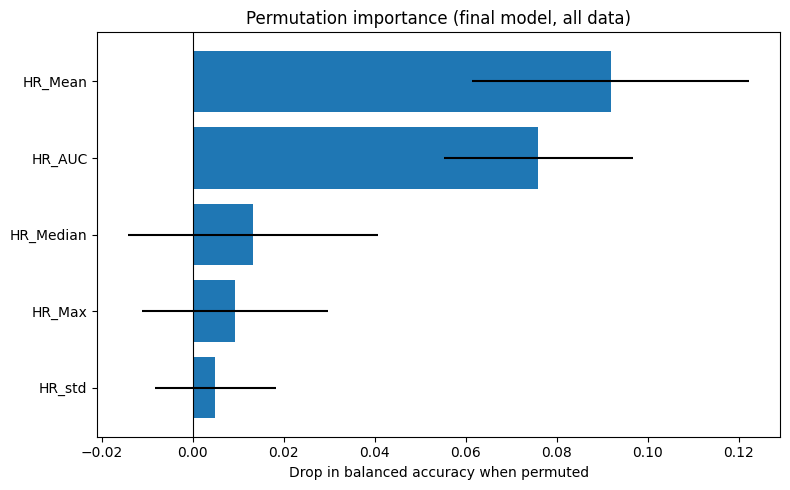

,Feature,Importance_mean,Importance_std
0,HR_Mean,0.091852,0.030385
4,HR_AUC,0.075926,0.020785
1,HR_Median,0.013280,0.027378
3,HR_Max,0.009365,0.020477
2,HR_std,0.005026,0.013319


In [13]:
perm_result = permutation_importance(
    final_model, X, y,
    scoring="balanced_accuracy", n_repeats=30, random_state=42
)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance_mean": perm_result.importances_mean,
    "Importance_std": perm_result.importances_std,
}).sort_values("Importance_mean", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance_mean"],
         xerr=importance_df["Importance_std"])
plt.xlabel("Drop in balanced accuracy when permuted")
plt.title("Permutation importance (final model, all data)")
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importance_df

## 11. Training curve (loss)

`MLPClassifier`'s `adam` solver stores the training loss at each iteration in `loss_curve_`, which
shows how the final model (refit on all 14 individuals) converged during training.

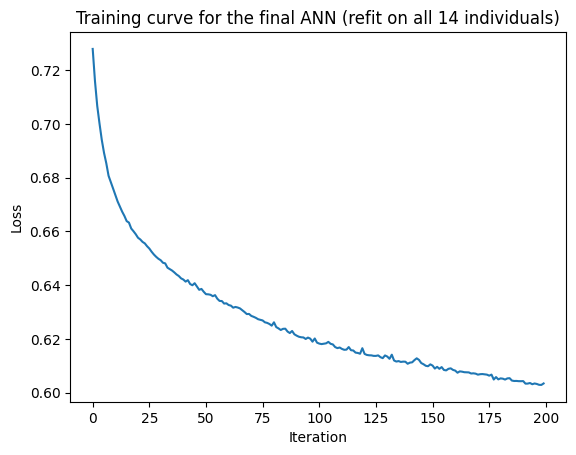

In [14]:
mlp = final_model.named_steps["clf"]

plt.plot(mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training curve for the final ANN (refit on all 14 individuals)")
plt.show()


## 12. Save out-of-fold results for model comparison

Finally, we save the pooled out-of-fold predictions (`oof_true`, `oof_pred`, `oof_proba`) and the
per-individual fold metrics to disk, so they can be compared against logistic regression in
`model_comparison.ipynb`.

In [15]:
np.savez(
    "results_ann.npz",
    model_name="ANN",
    oof_true=oof_true,
    oof_pred=oof_pred,
    oof_proba=oof_proba,
    fold_individual=fold_df["Individual"].to_numpy(),
    fold_accuracy=fold_df["accuracy"].to_numpy(),
    fold_balanced_accuracy=fold_df["balanced_accuracy"].to_numpy(),
)
print("Saved nested-LOSO results to results_ann.npz")

Saved nested-LOSO results to results_ann.npz
